# Interbank Network Data Exploration

**Author:** Ruben Marques  
**Purpose:** Comprehensive analysis of the interbank network dataset (2016-2023)

This notebook explores:
1. Dataset overview and structure
2. Network topology and connectivity
3. Bank features and distributions
4. Credit rating analysis
5. Temporal evolution
6. SRISK analysis

In [2]:
# Import libraries
import sys
import os

# Add src to path
sys.path.append(os.path.join(os.getcwd(), '..'))
sys.path.append(os.path.join(os.getcwd(), '..', 'src', 'data'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from src.data.data_loader import load_data, get_network_info, get_bank_labels

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


---
## 1. Dataset Overview

Load and examine the basic structure of the dataset.

In [3]:
# Load a sample quarter (2020 Q1 - pre-COVID for baseline)
year, quarter = 2020, 1
edges, nodes = load_data(year, quarter, data_path="../../interbank/datasets")

print(f"Dataset: {year} Q{quarter}")
print(f"\nEdges shape: {edges.shape}")
print(f"Nodes shape: {nodes.shape}")
print(f"\nEdge columns: {edges.columns.tolist()}")
print(f"\nNode columns (first 10): {nodes.columns.tolist()[:10]}")
print(f"Node columns (last 5): {nodes.columns.tolist()[-5:]}")

Loaded 2020 Q1: 4548 banks, 12424 connections
Dataset: 2020 Q1

Edges shape: (12424, 3)
Nodes shape: (4548, 74)

Edge columns: ['Sourceid', 'Targetid', 'Weights']

Node columns (first 10): ['index', 'Total_assets', 'Total_liabilities', 'Equity', 'Liquid_assets', 'Deposits_and_short-term_funding', 'Long-term_funding', 'Net_income', 'Interbank_assets', 'Interbank_liabilities']
Node columns (last 5): ['Non-interest_income_/_Operating_revenues', 'Net_interest_margin_(interest_earning_assets)', 'rank_next_quarter', 'srisk_ratio', 'srisk_value']


In [4]:
# Display sample data
print("=" * 60)
print("EDGE DATA SAMPLE")
print("=" * 60)
display(edges.head(10))

print("\n" + "=" * 60)
print("NODE DATA SAMPLE (first 10 columns)")
print("=" * 60)
display(nodes.iloc[:10, :10])

EDGE DATA SAMPLE


,Sourceid,Targetid,Weights
0,0,6,421160.113747
1,0,12,389722.619721
2,0,14,55946.603780
3,0,68,68307.024743
4,0,75,273.255907
5,0,154,230.162088
6,0,212,1193.437194
7,0,267,3023.368094
8,0,273,1783.680000
9,0,286,31377.000000



NODE DATA SAMPLE (first 10 columns)


,index,Total_assets,Total_liabilities,Equity,Liquid_assets,Deposits_and_short-term_funding,Long-term_funding,Net_income,Interbank_assets,Interbank_liabilities
0,0,2.690959e+09,2.447353e+09,2.436060e+08,1.289616e+09,2.062179e+09,9.523900e+07,1.688000e+06,4.309160e+08,1.926460e+08
1,1,2.031940e+09,1.824468e+09,2.074720e+08,5.596510e+08,1.735459e+09,9.942000e+06,3.498000e+06,1.653520e+08,5.898600e+07
2,2,1.632405e+09,1.479937e+09,1.524680e+08,7.010980e+08,1.288199e+09,6.133600e+07,1.923000e+06,1.923190e+08,6.969900e+07
3,3,1.763696e+09,1.593444e+09,1.702520e+08,4.986150e+08,1.475915e+09,6.927700e+07,2.079000e+06,7.550300e+07,3.168100e+07
4,4,1.101359e+09,1.034253e+09,6.710647e+07,5.162926e+08,8.163923e+08,1.146225e+08,2.258747e+06,1.510255e+08,1.070218e+08
5,5,1.115623e+09,1.052099e+09,6.352376e+07,7.295247e+08,7.753094e+08,1.200189e+08,2.651704e+06,2.686602e+08,1.964362e+08
6,6,8.720789e+08,8.192859e+08,5.279302e+07,3.871881e+08,6.098133e+08,1.118182e+08,1.757727e+06,1.552860e+08,1.101912e+08
7,7,6.647925e+08,6.253638e+08,3.942870e+07,2.599335e+08,4.510489e+08,9.391219e+07,1.203053e+06,8.515907e+07,8.121665e+07
8,8,6.712474e+08,6.562756e+08,1.497180e+07,2.060084e+08,3.213158e+08,5.711794e+07,0.000000e+00,1.087148e+08,1.164445e+08
9,9,5.079105e+08,4.782649e+08,2.964558e+07,1.406718e+08,3.617555e+08,6.845840e+07,9.158921e+05,5.535630e+07,4.458173e+07


In [5]:
# Basic statistics
stats = get_network_info(edges, nodes)

print("NETWORK STATISTICS")
print("=" * 60)
for key, value in stats.items():
    print(f"{key:30s}: {value:,.2f}" if isinstance(value, float) else f"{key:30s}: {value:,}")

NETWORK STATISTICS
num_banks                     : 4,548
num_connections               : 12,424
avg_connections_per_bank      : 2.73
total_exposure                : 94,168,371.55


---
## 2. Network Topology Analysis

Analyze the structure and connectivity of the interbank network.

In [6]:
# Create NetworkX graph
G = nx.DiGraph()

# Add edges with weights
for _, row in edges.iterrows():
    G.add_edge(row['Sourceid'], row['Targetid'], weight=row['Weights'])

print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
print(f"Is directed: {G.is_directed()}")
print(f"Is connected: {nx.is_weakly_connected(G)}")

Graph created with 4349 nodes and 12424 edges
Is directed: True
Is connected: True


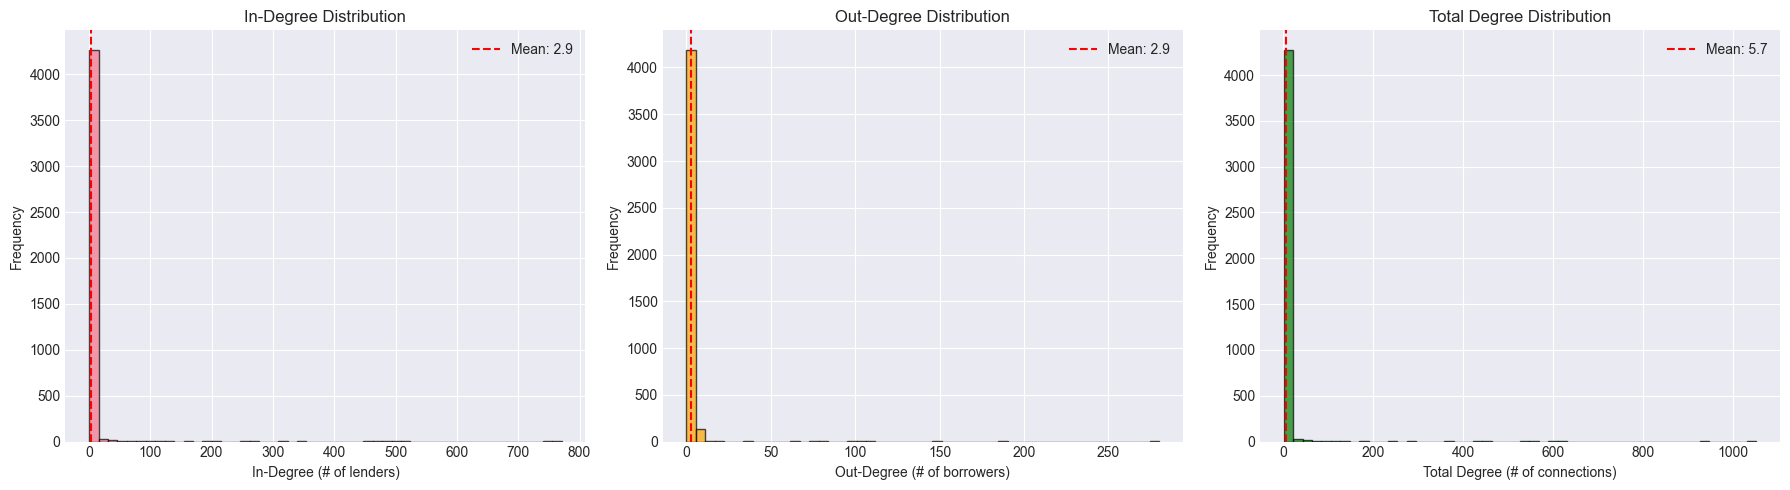

Average in-degree: 2.86
Average out-degree: 2.86
Average total degree: 5.71


In [7]:
# Degree distribution
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())
total_degrees = dict(G.degree())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# In-degree
axes[0].hist(list(in_degrees.values()), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('In-Degree (# of lenders)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('In-Degree Distribution')
axes[0].axvline(np.mean(list(in_degrees.values())), color='r', linestyle='--', label=f'Mean: {np.mean(list(in_degrees.values())):.1f}')
axes[0].legend()

# Out-degree
axes[1].hist(list(out_degrees.values()), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Out-Degree (# of borrowers)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Out-Degree Distribution')
axes[1].axvline(np.mean(list(out_degrees.values())), color='r', linestyle='--', label=f'Mean: {np.mean(list(out_degrees.values())):.1f}')
axes[1].legend()

# Total degree
axes[2].hist(list(total_degrees.values()), bins=50, edgecolor='black', alpha=0.7, color='green')
axes[2].set_xlabel('Total Degree (# of connections)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Total Degree Distribution')
axes[2].axvline(np.mean(list(total_degrees.values())), color='r', linestyle='--', label=f'Mean: {np.mean(list(total_degrees.values())):.1f}')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Average in-degree: {np.mean(list(in_degrees.values())):.2f}")
print(f"Average out-degree: {np.mean(list(out_degrees.values())):.2f}")
print(f"Average total degree: {np.mean(list(total_degrees.values())):.2f}")

c:\Users\ruben\Desktop\Universidade\Nova IMS\Tese\Codigo\Codigo\Tese_code\venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


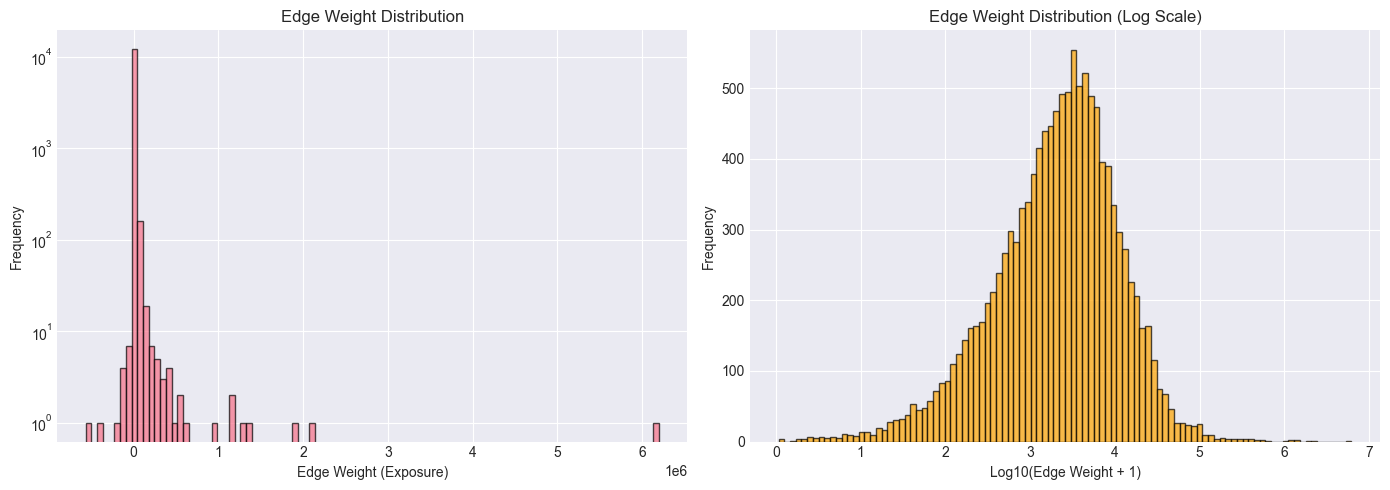

Total exposure: $94,168,372
Mean exposure: $7,580
Median exposure: $2,381
Max exposure: $6,192,340
Min exposure: $-563,443


In [8]:
# Edge weight distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw weights
axes[0].hist(edges['Weights'], bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Edge Weight (Exposure)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Edge Weight Distribution')
axes[0].set_yscale('log')

# Log weights
axes[1].hist(np.log10(edges['Weights'] + 1), bins=100, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Log10(Edge Weight + 1)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Edge Weight Distribution (Log Scale)')

plt.tight_layout()
plt.show()

print(f"Total exposure: ${edges['Weights'].sum():,.0f}")
print(f"Mean exposure: ${edges['Weights'].mean():,.0f}")
print(f"Median exposure: ${edges['Weights'].median():,.0f}")
print(f"Max exposure: ${edges['Weights'].max():,.0f}")
print(f"Min exposure: ${edges['Weights'].min():,.0f}")

---
## 3. Bank Features Analysis

Examine the distribution of bank financial features.

In [9]:
# Get feature columns (exclude index and last 3 columns)
feature_cols = nodes.columns[1:-3].tolist()

print(f"Total features: {len(feature_cols)}")
print(f"\nFirst 10 features:")
for i, col in enumerate(feature_cols[:10], 1):
    print(f"{i:2d}. {col}")

Total features: 70

First 10 features:
 1. Total_assets
 2. Total_liabilities
 3. Equity
 4. Liquid_assets
 5. Deposits_and_short-term_funding
 6. Long-term_funding
 7. Net_income
 8. Interbank_assets
 9. Interbank_liabilities
10. Return_on_average_equity_(ROAE)


In [10]:
# Check for missing values
missing = nodes[feature_cols].isnull().sum()
missing_pct = (missing / len(nodes)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)

print("FEATURES WITH MISSING VALUES")
print("=" * 60)
display(missing_df[missing_df['Missing Count'] > 0].head(20))

print(f"\nFeatures with >50% missing: {(missing_pct > 50).sum()}")
print(f"Features with no missing values: {(missing == 0).sum()}")

FEATURES WITH MISSING VALUES


,Missing Count,Missing %



Features with >50% missing: 0
Features with no missing values: 70


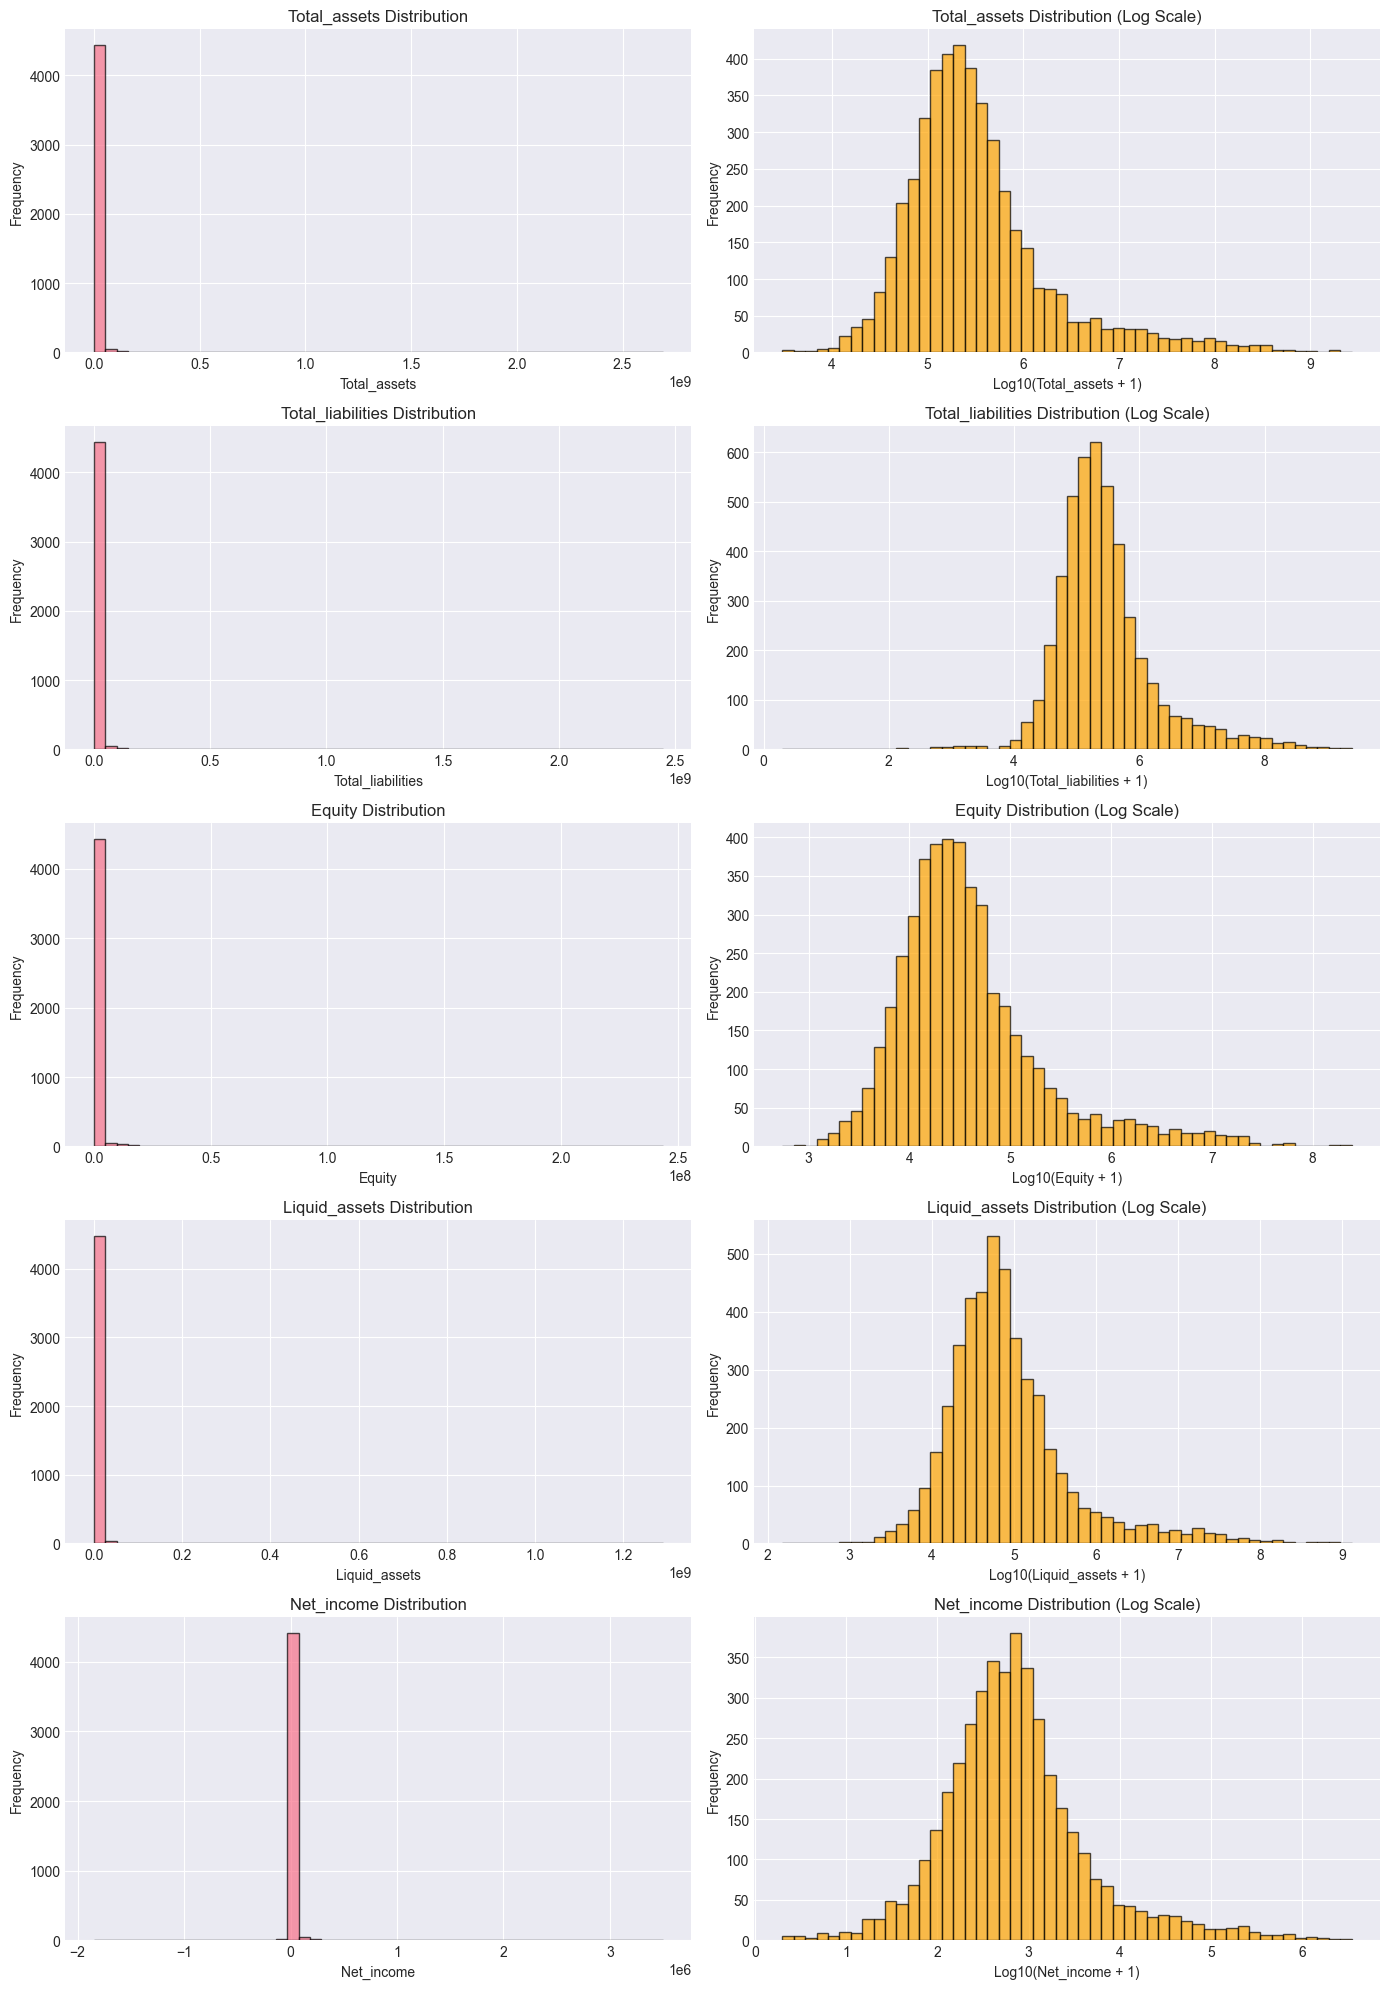

In [11]:
# Distribution of key financial features
key_features = ['Total_assets', 'Total_liabilities', 'Equity', 'Liquid_assets', 'Net_income']

# Check which features exist
available_features = [f for f in key_features if f in nodes.columns]

if available_features:
    fig, axes = plt.subplots(len(available_features), 2, figsize=(14, 4*len(available_features)))
    
    for i, feature in enumerate(available_features):
        data = nodes[feature].dropna()
        
        # Original scale
        axes[i, 0].hist(data, bins=50, edgecolor='black', alpha=0.7)
        axes[i, 0].set_xlabel(feature)
        axes[i, 0].set_ylabel('Frequency')
        axes[i, 0].set_title(f'{feature} Distribution')
        
        # Log scale
        log_data = np.log10(data[data > 0] + 1)
        axes[i, 1].hist(log_data, bins=50, edgecolor='black', alpha=0.7, color='orange')
        axes[i, 1].set_xlabel(f'Log10({feature} + 1)')
        axes[i, 1].set_ylabel('Frequency')
        axes[i, 1].set_title(f'{feature} Distribution (Log Scale)')
    
    plt.tight_layout()
    plt.show()
else:
    print("Key features not found in dataset")

---
## 4. Credit Rating Analysis

Analyze the distribution of credit ratings and their relationship with other variables.

CREDIT RATING DISTRIBUTION
rating
1     405
2    1090
3    2179
4     874
Name: count, dtype: int64


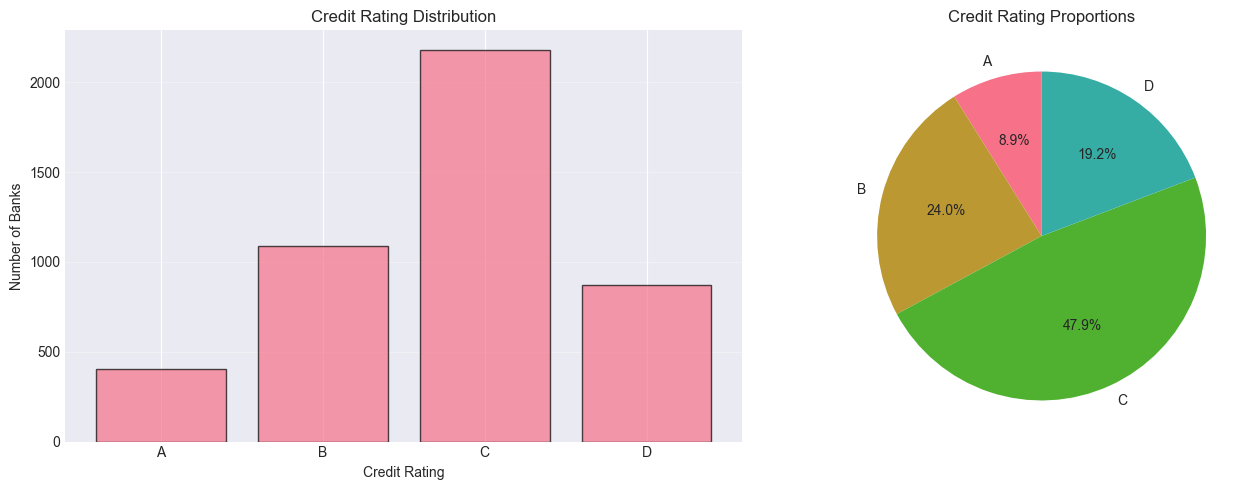


Banks with ratings: 4548 (100.0%)
Banks without ratings: 0 (0.0%)


In [12]:
# Get bank labels
labels = get_bank_labels(nodes)

print("CREDIT RATING DISTRIBUTION")
print("=" * 60)
print(labels['rating'].value_counts().sort_index())

# Plot rating distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
rating_counts = labels['rating'].value_counts().sort_index()
rating_names = {1.0: 'A', 2.0: 'B', 3.0: 'C', 4.0: 'D'}
rating_labels = [rating_names.get(r, 'Unknown') for r in rating_counts.index]

axes[0].bar(rating_labels, rating_counts.values, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Credit Rating')
axes[0].set_ylabel('Number of Banks')
axes[0].set_title('Credit Rating Distribution')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(rating_counts.values, labels=rating_labels, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Credit Rating Proportions')

plt.tight_layout()
plt.show()

print(f"\nBanks with ratings: {labels['rating'].notna().sum()} ({labels['rating'].notna().sum()/len(labels)*100:.1f}%)")
print(f"Banks without ratings: {labels['rating'].isna().sum()} ({labels['rating'].isna().sum()/len(labels)*100:.1f}%)")

---
## 5. SRISK Analysis

Analyze systemic risk measures (SRISK ratio and value).

In [13]:
# SRISK statistics
print("SRISK STATISTICS")
print("=" * 60)
print("\nSRISK Ratio:")
print(nodes['srisk_ratio'].describe())
print("\nSRISK Value:")
print(nodes['srisk_value'].describe())

SRISK STATISTICS

SRISK Ratio:
count    284.000000
mean       0.311655
std        1.022864
min        0.000000
25%        0.000000
50%        0.010000
75%        0.092500
max        7.320000
Name: srisk_ratio, dtype: float64

SRISK Value:
count       284.000000
mean       3100.964437
std       13662.895920
min      -23242.500000
25%         -42.150000
50%          83.800000
75%        1169.150000
max      119317.600000
Name: srisk_value, dtype: float64


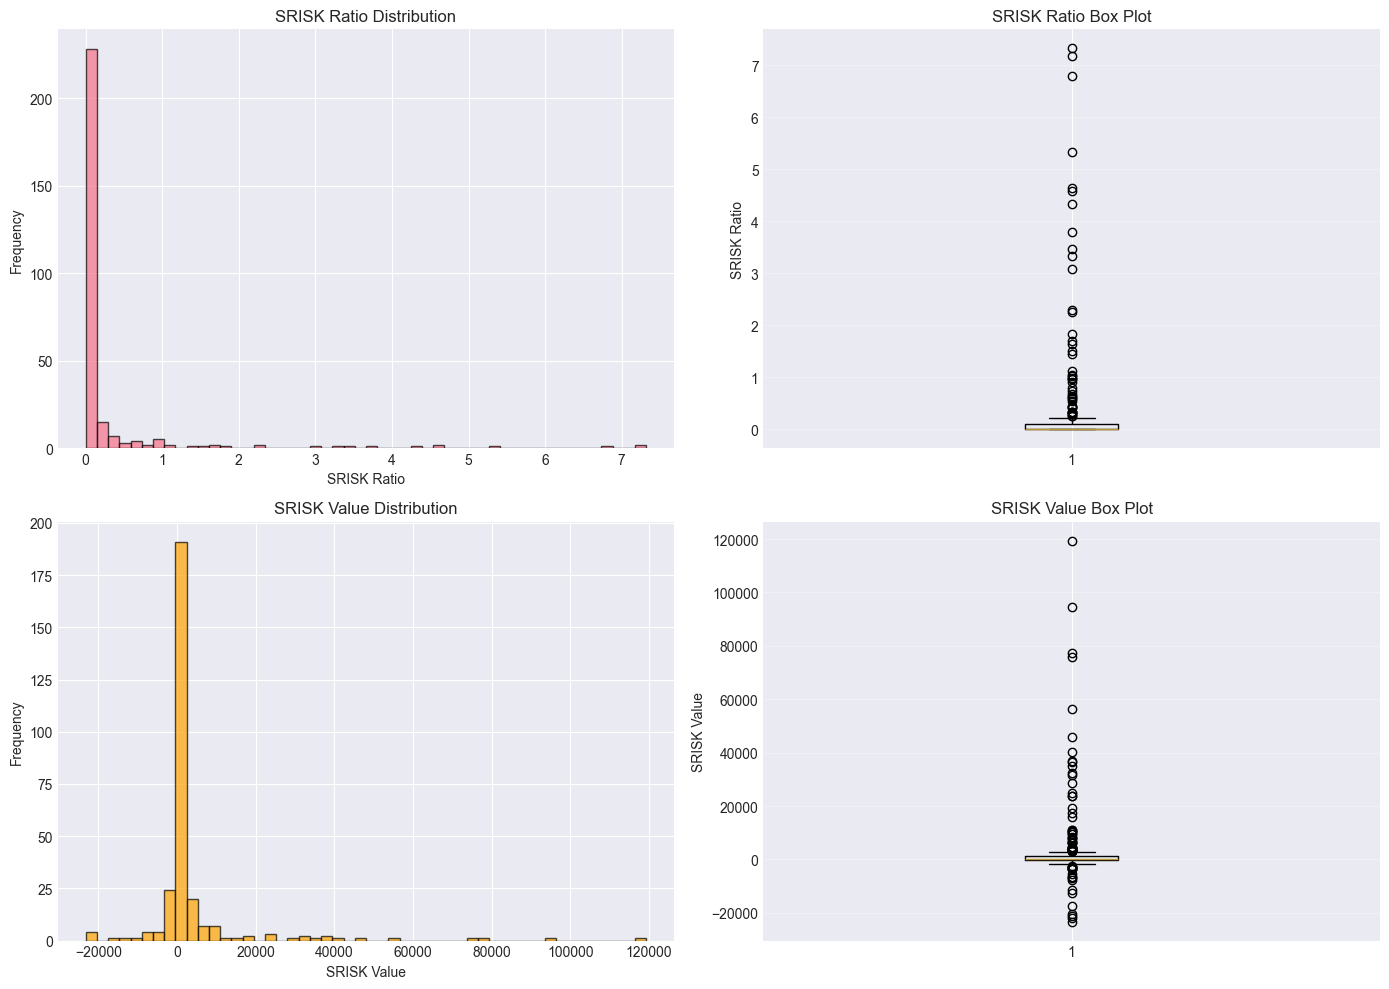

In [14]:
# SRISK distribution plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# SRISK ratio
srisk_ratio_clean = nodes['srisk_ratio'].dropna()
axes[0, 0].hist(srisk_ratio_clean, bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('SRISK Ratio')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('SRISK Ratio Distribution')

axes[0, 1].boxplot(srisk_ratio_clean, vert=True)
axes[0, 1].set_ylabel('SRISK Ratio')
axes[0, 1].set_title('SRISK Ratio Box Plot')
axes[0, 1].grid(axis='y', alpha=0.3)

# SRISK value
srisk_value_clean = nodes['srisk_value'].dropna()
axes[1, 0].hist(srisk_value_clean, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].set_xlabel('SRISK Value')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('SRISK Value Distribution')

axes[1, 1].boxplot(srisk_value_clean, vert=True)
axes[1, 1].set_ylabel('SRISK Value')
axes[1, 1].set_title('SRISK Value Box Plot')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. Temporal Evolution (2016-2023)

Analyze how the network evolves over time.

In [15]:
# Load all quarters and track evolution
years = range(2016, 2023)
quarters = range(1, 5)

timeline_data = []

for year in years:
    for quarter in quarters:
        try:
            edges_t, nodes_t = load_data(year, quarter)
            stats_t = get_network_info(edges_t, nodes_t)
            labels_t = get_bank_labels(nodes_t)
            
            timeline_data.append({
                'year': year,
                'quarter': quarter,
                'period': f"{year}Q{quarter}",
                'num_banks': stats_t['num_banks'],
                'num_connections': stats_t['num_connections'],
                'total_exposure': stats_t['total_exposure'],
                'avg_connections': stats_t['avg_connections_per_bank'],
                'banks_with_ratings': labels_t['rating'].notna().sum(),
                'rating_A': (labels_t['rating'] == 1).sum(),
                'rating_B': (labels_t['rating'] == 2).sum(),
                'rating_C': (labels_t['rating'] == 3).sum(),
                'rating_D': (labels_t['rating'] == 4).sum(),
            })
        except FileNotFoundError:
            print(f"Data not found for {year} Q{quarter}")
            continue

timeline_df = pd.DataFrame(timeline_data)
print(f"Loaded {len(timeline_df)} quarters of data")
display(timeline_df.head(10))

Loaded 2016 Q1: 4548 banks, 11631 connections
Loaded 2016 Q2: 4548 banks, 11632 connections
Loaded 2016 Q3: 4548 banks, 11937 connections
Loaded 2016 Q4: 4548 banks, 11938 connections
Loaded 2017 Q1: 4548 banks, 11939 connections
Loaded 2017 Q2: 4548 banks, 11940 connections
Loaded 2017 Q3: 4548 banks, 11941 connections
Loaded 2017 Q4: 4548 banks, 11981 connections
Loaded 2018 Q1: 4548 banks, 12416 connections
Loaded 2018 Q2: 4548 banks, 12417 connections
Loaded 2018 Q3: 4548 banks, 12418 connections
Loaded 2018 Q4: 4548 banks, 12419 connections
Loaded 2019 Q1: 4548 banks, 12420 connections
Loaded 2019 Q2: 4548 banks, 12421 connections
Loaded 2019 Q3: 4548 banks, 12422 connections
Loaded 2019 Q4: 4548 banks, 12423 connections
Loaded 2020 Q1: 4548 banks, 12424 connections
Loaded 2020 Q2: 4548 banks, 12451 connections
Loaded 2020 Q3: 4548 banks, 12452 connections
Loaded 2020 Q4: 4548 banks, 12453 connections
Loaded 2021 Q1: 4548 banks, 12454 connections
Loaded 2021 Q2: 4548 banks, 12455 

,year,quarter,period,num_banks,num_connections,total_exposure,avg_connections,banks_with_ratings,rating_A,rating_B,rating_C,rating_D
0,2016,1,2016Q1,4548,11631,1.809296e+09,2.557388,4548,860,1001,1829,858
1,2016,2,2016Q2,4548,11632,9.315245e+08,2.557608,4548,710,1284,1193,1361
2,2016,3,2016Q3,4548,11937,5.849129e+08,2.624670,4548,545,1251,1079,1673
3,2016,4,2016Q4,4548,11938,4.174992e+08,2.624890,4548,463,1143,1566,1376
4,2017,1,2017Q1,4548,11939,2.362759e+08,2.625110,4548,410,1122,1795,1221
5,2017,2,2017Q2,4548,11940,1.714674e+08,2.625330,4548,1108,1406,1307,727
6,2017,3,2017Q3,4548,11941,1.366123e+08,2.625550,4548,1105,1761,1183,499
7,2017,4,2017Q4,4548,11981,1.135293e+08,2.634345,4548,880,1242,1405,1021
8,2018,1,2018Q1,4548,12416,1.106005e+08,2.729991,4548,1323,1453,950,822
9,2018,2,2018Q2,4548,12417,1.065535e+08,2.730211,4548,1101,1446,1097,904


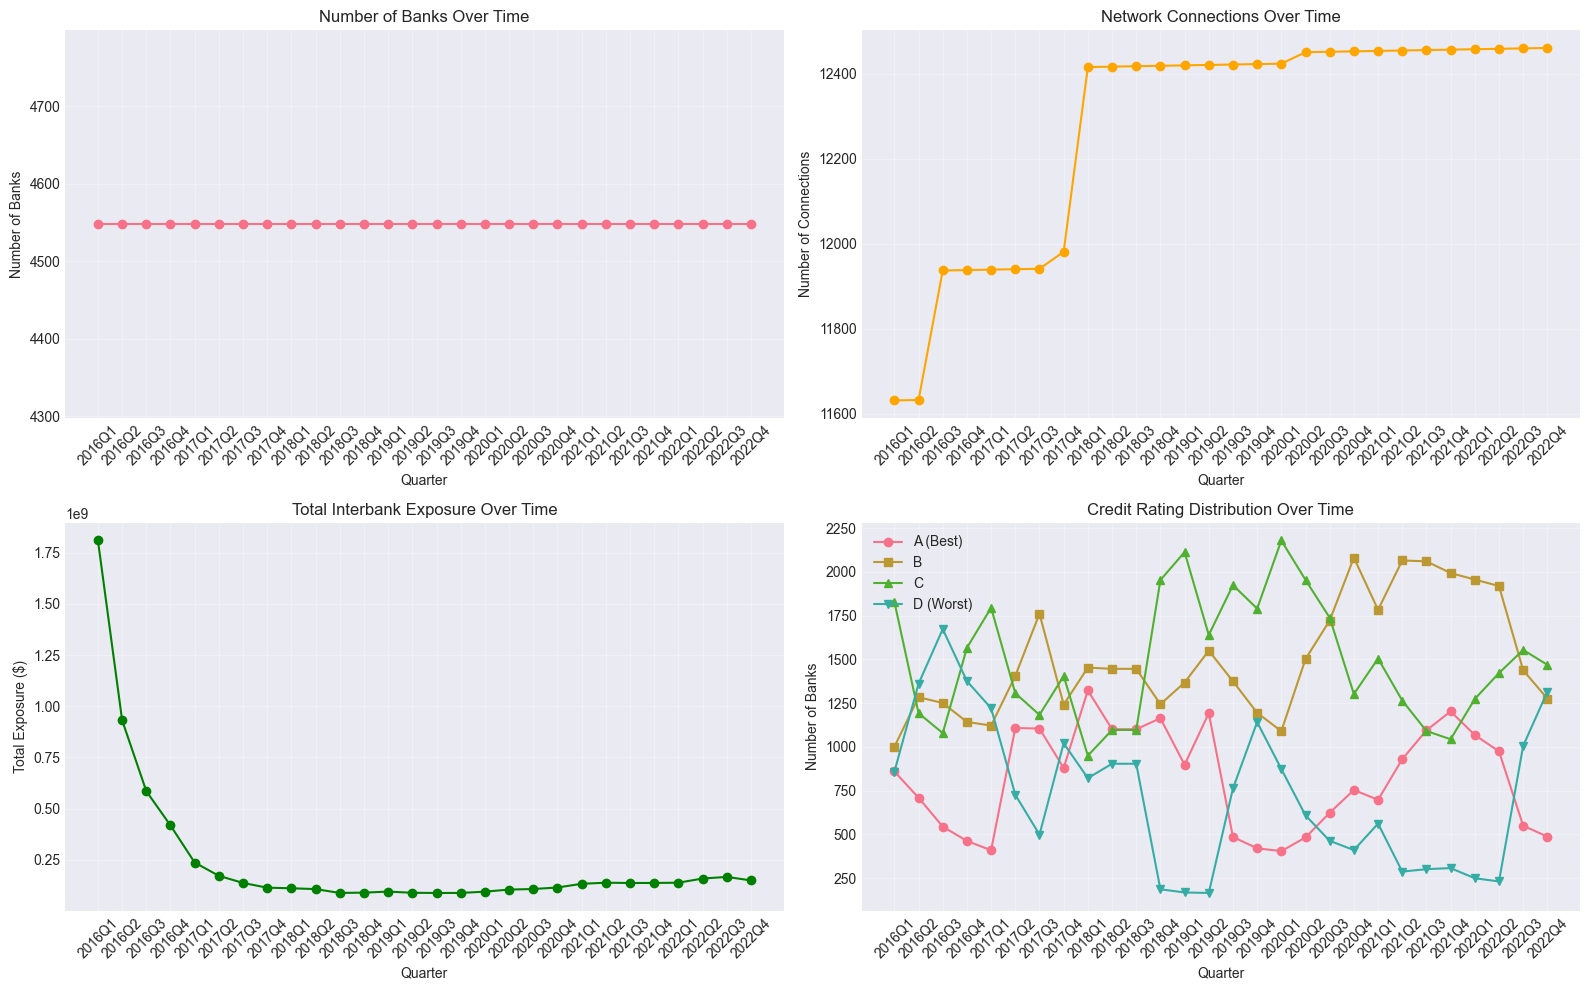

In [16]:
# Plot temporal evolution
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Number of banks
axes[0, 0].plot(timeline_df['period'], timeline_df['num_banks'], marker='o')
axes[0, 0].set_xlabel('Quarter')
axes[0, 0].set_ylabel('Number of Banks')
axes[0, 0].set_title('Number of Banks Over Time')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(alpha=0.3)

# Number of connections
axes[0, 1].plot(timeline_df['period'], timeline_df['num_connections'], marker='o', color='orange')
axes[0, 1].set_xlabel('Quarter')
axes[0, 1].set_ylabel('Number of Connections')
axes[0, 1].set_title('Network Connections Over Time')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(alpha=0.3)

# Total exposure
axes[1, 0].plot(timeline_df['period'], timeline_df['total_exposure'], marker='o', color='green')
axes[1, 0].set_xlabel('Quarter')
axes[1, 0].set_ylabel('Total Exposure ($)')
axes[1, 0].set_title('Total Interbank Exposure Over Time')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(alpha=0.3)

# Rating distribution
axes[1, 1].plot(timeline_df['period'], timeline_df['rating_A'], marker='o', label='A (Best)')
axes[1, 1].plot(timeline_df['period'], timeline_df['rating_B'], marker='s', label='B')
axes[1, 1].plot(timeline_df['period'], timeline_df['rating_C'], marker='^', label='C')
axes[1, 1].plot(timeline_df['period'], timeline_df['rating_D'], marker='v', label='D (Worst)')
axes[1, 1].set_xlabel('Quarter')
axes[1, 1].set_ylabel('Number of Banks')
axes[1, 1].set_title('Credit Rating Distribution Over Time')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 7. Key Insights Summary

Summarize the main findings from the analysis.

In [17]:
print("=" * 80)
print("KEY INSIGHTS FROM DATA EXPLORATION")
print("=" * 80)

print("\n1. DATASET SIZE:")
print(f"   - Time period: {timeline_df['year'].min()}-{timeline_df['year'].max()}")
print(f"   - Total quarters: {len(timeline_df)}")
print(f"   - Average banks per quarter: {timeline_df['num_banks'].mean():.0f}")
print(f"   - Average connections per quarter: {timeline_df['num_connections'].mean():.0f}")

print("\n2. NETWORK STRUCTURE:")
print(f"   - Network density: {timeline_df['avg_connections'].mean():.2f} connections per bank")
print(f"   - Total exposure range: ${timeline_df['total_exposure'].min():,.0f} - ${timeline_df['total_exposure'].max():,.0f}")

print("\n3. CREDIT RATINGS:")
print(f"   - Banks with ratings: ~{timeline_df['banks_with_ratings'].mean():.0f} per quarter")
print(f"   - Average A-rated banks: {timeline_df['rating_A'].mean():.0f}")
print(f"   - Average B-rated banks: {timeline_df['rating_B'].mean():.0f}")
print(f"   - Average C-rated banks: {timeline_df['rating_C'].mean():.0f}")
print(f"   - Average D-rated banks: {timeline_df['rating_D'].mean():.0f}")

print("\n4. DATA QUALITY:")
print(f"   - Features with missing values: {(nodes[feature_cols].isnull().sum() > 0).sum()} out of {len(feature_cols)}")
print(f"   - Complete features: {(nodes[feature_cols].isnull().sum() == 0).sum()}")

print("\n" + "=" * 80)
print("✅ Data exploration complete!")
print("=" * 80)

KEY INSIGHTS FROM DATA EXPLORATION

1. DATASET SIZE:
   - Time period: 2016-2022
   - Total quarters: 28
   - Average banks per quarter: 4548
   - Average connections per quarter: 12276

2. NETWORK STRUCTURE:
   - Network density: 2.70 connections per bank
   - Total exposure range: $87,668,687 - $1,809,295,720

3. CREDIT RATINGS:
   - Banks with ratings: ~4548 per quarter
   - Average A-rated banks: 823
   - Average B-rated banks: 1506
   - Average C-rated banks: 1490
   - Average D-rated banks: 729

4. DATA QUALITY:
   - Features with missing values: 0 out of 70
   - Complete features: 70

✅ Data exploration complete!


# Visualization with all the banks

In [20]:
# For large networks, we'll visualize a subset
# Let's take the top 50 most connected banks
top_n = 100
top_nodes = sorted(total_degrees.items(), key=lambda x: x[1], reverse=True)[:top_n]
top_node_ids = [node for node, degree in top_nodes]

# Create subgraph
G_sub = G.subgraph(top_node_ids).copy()

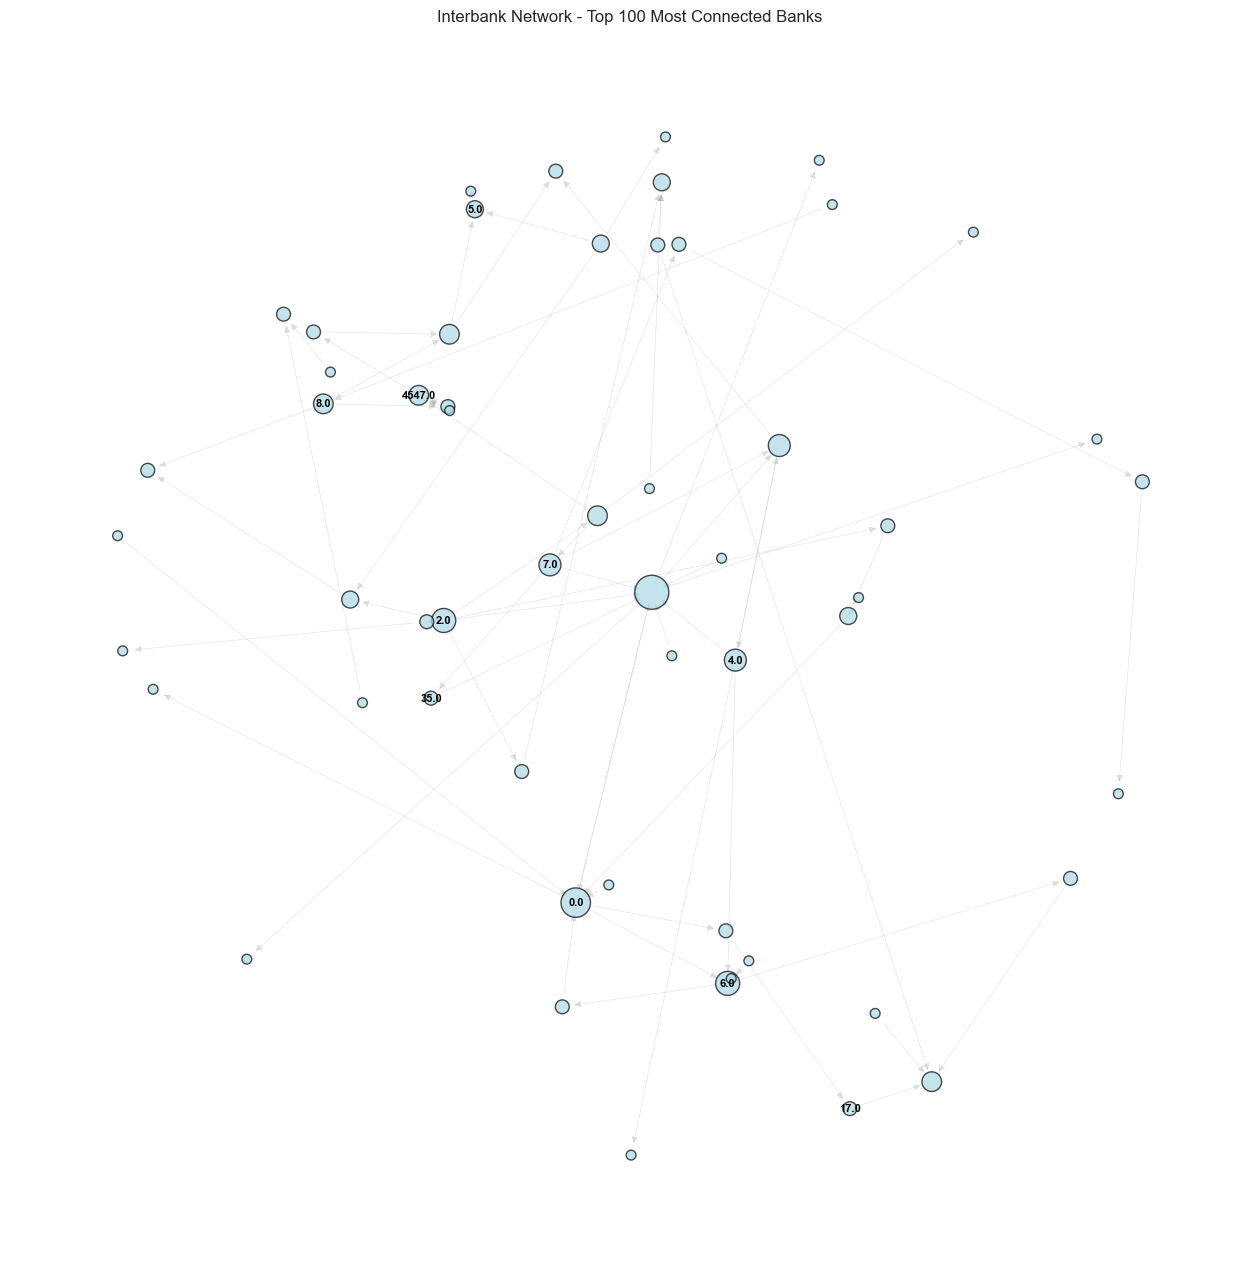

In [21]:
plt.figure(figsize=(16, 16))

# Use spring layout for positioning
pos = nx.spring_layout(G_sub, k=2, iterations=50, seed=42)

# Node sizes based on degree
node_sizes = [G_sub.degree(node) * 50 for node in G_sub.nodes()]

# Draw network
nx.draw_networkx_nodes(G_sub, pos, 
                       node_size=node_sizes,
                       node_color='lightblue',
                       alpha=0.7,
                       edgecolors='black')

nx.draw_networkx_edges(G_sub, pos, 
                       alpha=0.2,
                       arrows=True,
                       arrowsize=10,
                       width=0.5,
                       edge_color='gray')

# Add labels for top 10 most connected
top_10_nodes = dict(sorted(top_nodes[:10]))
labels = {node: str(node) for node in top_10_nodes.keys()}
nx.draw_networkx_labels(G_sub, pos, labels, font_size=8, font_weight='bold')

plt.title(f'Interbank Network - Top {top_n} Most Connected Banks')
plt.axis('off')
plt.show()

In [23]:
!pip install pyvis

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ---------------------------------------- 0.0/756.0 kB ? eta -:--:--
   --------------------------------------- 756.0/756.0 kB 38.0 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
from pyvis.network import Network

# Create PyVis network
net = Network(height='750px', width='100%', 
              bgcolor='#222222', font_color='white',
              notebook=True, directed=True,
              cdn_resources='remote')  # Fix for Chrome/Safari display

# Add nodes with sizes based on degree
# Add nodes with sizes based on degree
for node in G_sub.nodes():
    degree = G_sub.degree(node)
    net.add_node(int(node),  # Convert to regular Python int
                label=str(node),
                size=degree*2,
                title=f'Bank {node}<br>Degree: {degree}',
                color='#00ff1e')

# Add edges
for source, target, data in G_sub.edges(data=True):
    weight = data.get('weight', 1)
    net.add_edge(int(source), int(target),  # Convert to regular Python int
                value=weight/1000,
                title=f'Exposure: ${weight:,.0f}')

# Show the network
net.show('network_visualization.html')

network_visualization.html
